# Bag-of-Words Image Classifier

This notebook implements a scene classification pipeline using the Bag-of-Words (BoW) approach on the 15-scene dataset (Lazebnik et al., 2006).

The pipeline consists of five steps:
1. Load the dataset
2. Extract SIFT local descriptors from each image
3. Build a visual vocabulary with k-means
4. Encode each image as a normalized histogram of visual words
5. Train and evaluate a 1-NN baseline and a linear SVM

## 1. Setup

In [1]:
import sys
import os
import pathlib
import numpy as np
import joblib
from sklearn.model_selection import train_test_split

# Set working directory to the project root regardless of how Jupyter was launched
try:
    ROOT = pathlib.Path(__vsc_ipynb_file__).parent
except NameError:
    ROOT = pathlib.Path.cwd()
os.chdir(ROOT)

sys.path.insert(0, str(ROOT / 'src'))
os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

from features import extract_descriptors
from vocabulary import build_vocabulary, encode_bow
from classifier import train_knn, train_svm, evaluate
from utils import load_dataset, plot_accuracy_vs_k, plot_confusion_matrix

RANDOM_SEED = 42
TRAIN_PATH = 'dataset/train'
TEST_PATH  = 'dataset/test'

## 2. Load the dataset

Images are organized in subfolders, one per category. We load the file paths and assign an integer label to each category.

In [2]:
train_paths, train_labels, categories = load_dataset(TRAIN_PATH)
test_paths,  test_labels,  _          = load_dataset(TEST_PATH)

print(f"Categories ({len(categories)}): {categories}")
print(f"Training images : {len(train_paths)}")
print(f"Test images     : {len(test_paths)}")

Categories (15): ['Bedroom', 'Coast', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Training images : 1500
Test images     : 2985


We set aside 15% of the training set as a validation set. The validation set is used only to select the vocabulary size k; the test set is used only once at the end.

In [3]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=0.15,
    stratify=train_labels,
    random_state=RANDOM_SEED
)

print(f"Training   : {len(train_paths)} images")
print(f"Validation : {len(val_paths)} images")
print(f"Test       : {len(test_paths)} images")

Training   : 1275 images
Validation : 225 images
Test       : 2985 images


## 3. Extract SIFT descriptors

SIFT (Scale-Invariant Feature Transform) detects keypoints and computes a 128-dimensional descriptor for each one. Descriptors are invariant to scale and rotation, which makes them suitable for matching across different images of the same scene.

We extract descriptors from all three splits. The vocabulary will be built only from the training descriptors.

In [4]:
print("Extracting SIFT from training set...")
train_desc = extract_descriptors(train_paths)

print("Extracting SIFT from validation set...")
val_desc = extract_descriptors(val_paths)

print("Extracting SIFT from test set...")
test_desc = extract_descriptors(test_paths)

Extracting SIFT from training set...
  100/1275 images processed
  200/1275 images processed
  300/1275 images processed
  400/1275 images processed
  500/1275 images processed
  600/1275 images processed
  700/1275 images processed
  800/1275 images processed
  900/1275 images processed
  1000/1275 images processed
  1100/1275 images processed
  1200/1275 images processed
  1275/1275 images processed
Extracting SIFT from validation set...
  100/225 images processed
  200/225 images processed
  225/225 images processed
Extracting SIFT from test set...
  100/2985 images processed
  200/2985 images processed
  300/2985 images processed
  400/2985 images processed
  500/2985 images processed
  600/2985 images processed
  700/2985 images processed
  800/2985 images processed
  900/2985 images processed
  1000/2985 images processed
  1100/2985 images processed
  1200/2985 images processed
  1300/2985 images processed
  1400/2985 images processed
  1500/2985 images processed
  1600/2985 imag

## 4. Select vocabulary size k

The vocabulary is a set of k representative descriptors (visual words) obtained by clustering all training descriptors with k-means. Each descriptor is then assigned to its nearest visual word.

The choice of k is a trade-off: too few words and the representation is too coarse; too many words and the histogram becomes sparse and noisy. We try several values and select the one with the best validation accuracy.

In [5]:
k_values = [50, 100, 200, 500]

knn_val_accuracies = []
svm_val_accuracies = []

for k in k_values:
    print(f"\n--- k = {k} ---")

    # Build vocabulary from training descriptors only
    vocab = build_vocabulary(train_desc, k=k, random_seed=RANDOM_SEED)

    # Encode images as BoW histograms
    X_train = encode_bow(train_desc, vocab)
    X_val   = encode_bow(val_desc,   vocab)

    # 1-NN
    knn = train_knn(X_train, train_labels)
    _, knn_acc = evaluate(knn, X_val, val_labels)
    knn_val_accuracies.append(knn_acc * 100)
    print(f"  1-NN  accuracy: {knn_acc * 100:.1f}%")

    # Linear SVM
    svm = train_svm(X_train, train_labels, C=1.0, random_seed=RANDOM_SEED)
    _, svm_acc = evaluate(svm, X_val, val_labels)
    svm_val_accuracies.append(svm_acc * 100)
    print(f"  SVM   accuracy: {svm_acc * 100:.1f}%")


--- k = 50 ---
  Total descriptors for clustering: 640959
  1-NN  accuracy: 32.9%
  SVM   accuracy: 36.0%

--- k = 100 ---
  Total descriptors for clustering: 640959
  1-NN  accuracy: 32.9%
  SVM   accuracy: 42.2%

--- k = 200 ---
  Total descriptors for clustering: 640959
  1-NN  accuracy: 30.7%
  SVM   accuracy: 40.9%

--- k = 500 ---
  Total descriptors for clustering: 640959
  1-NN  accuracy: 28.0%
  SVM   accuracy: 40.0%


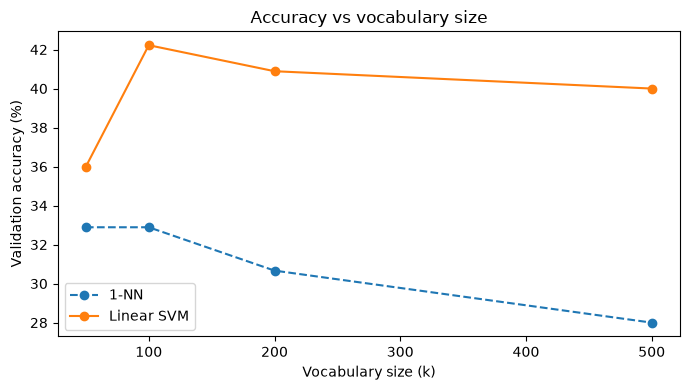

In [6]:
plot_accuracy_vs_k(k_values, knn_val_accuracies, svm_val_accuracies)

## 5. Final evaluation on the test set

We select the value of k that gave the best SVM validation accuracy. As an intermediate check, we first show the confusion matrices on the validation set (models trained on the training subset only). We then retrain on the full training set (train + validation combined), save the vocabulary centroids and the SVM to disk, and evaluate once on the test set.

Best k (by SVM validation accuracy): 100
  Total descriptors for clustering: 640959


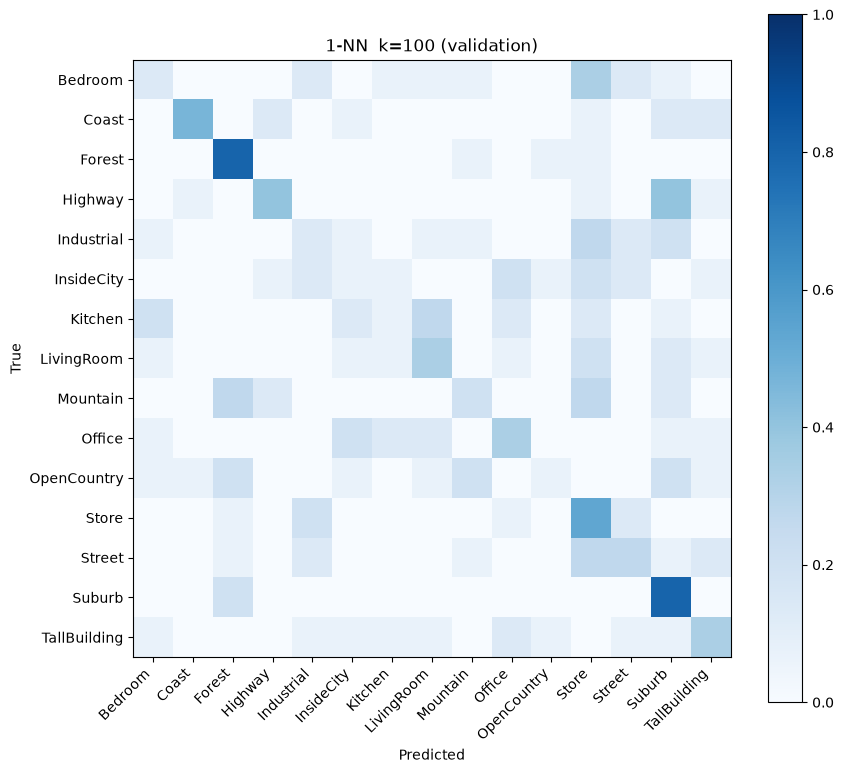

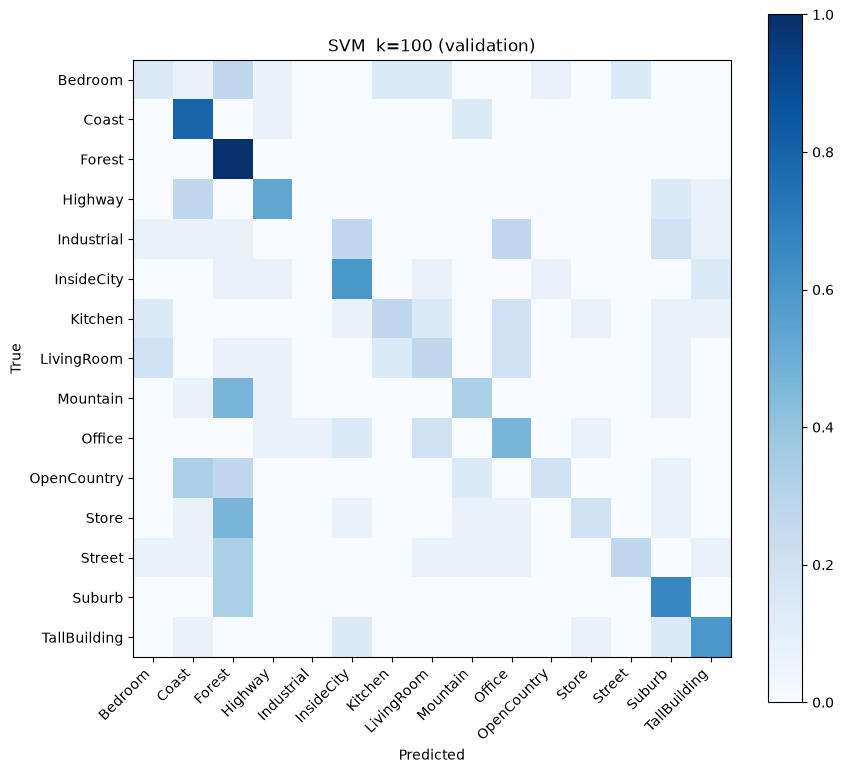

  Total descriptors for clustering: 762342
Vocabulary saved  : models/vocabulary_k100.pkl
1-NN  test accuracy : 35.0%
SVM   test accuracy : 42.9%
SVM saved         : models/svm_k100.pkl


In [7]:
best_k = k_values[int(np.argmax(svm_val_accuracies))]
print(f"Best k (by SVM validation accuracy): {best_k}")

# Intermediate check: confusion matrices on the validation set
# Models trained on the training subset only (not train+val)
vocab_val_check = build_vocabulary(train_desc, k=best_k, random_seed=RANDOM_SEED)
X_tr_check  = encode_bow(train_desc, vocab_val_check)
X_val_check = encode_bow(val_desc,   vocab_val_check)

knn_val_check = train_knn(X_tr_check, train_labels)
knn_preds_val, _ = evaluate(knn_val_check, X_val_check, val_labels)
plot_confusion_matrix(val_labels, knn_preds_val, categories,
                      title=f'1-NN  k={best_k} (validation)')

svm_val_check = train_svm(X_tr_check, train_labels, C=1.0, random_seed=RANDOM_SEED)
svm_preds_val, _ = evaluate(svm_val_check, X_val_check, val_labels)
plot_confusion_matrix(val_labels, svm_preds_val, categories,
                      title=f'SVM  k={best_k} (validation)')

# Retrain on full training set (train + val) for final evaluation
final_desc   = train_desc + val_desc
final_labels = np.concatenate([train_labels, val_labels])

vocab_final = build_vocabulary(final_desc, k=best_k, random_seed=RANDOM_SEED)
joblib.dump(vocab_final, f'models/vocabulary_k{best_k}.pkl')
print(f"Vocabulary saved  : models/vocabulary_k{best_k}.pkl")

X_train_final = encode_bow(final_desc, vocab_final)
X_test_final  = encode_bow(test_desc,  vocab_final)

knn_final = train_knn(X_train_final, final_labels)
knn_preds, knn_test_acc = evaluate(knn_final, X_test_final, test_labels)
print(f"1-NN  test accuracy : {knn_test_acc * 100:.1f}%")

svm_final = train_svm(X_train_final, final_labels, C=1.0, random_seed=RANDOM_SEED)
svm_preds, svm_test_acc = evaluate(svm_final, X_test_final, test_labels)
print(f"SVM   test accuracy : {svm_test_acc * 100:.1f}%")

joblib.dump(svm_final, f'models/svm_k{best_k}.pkl')
print(f"SVM saved         : models/svm_k{best_k}.pkl")

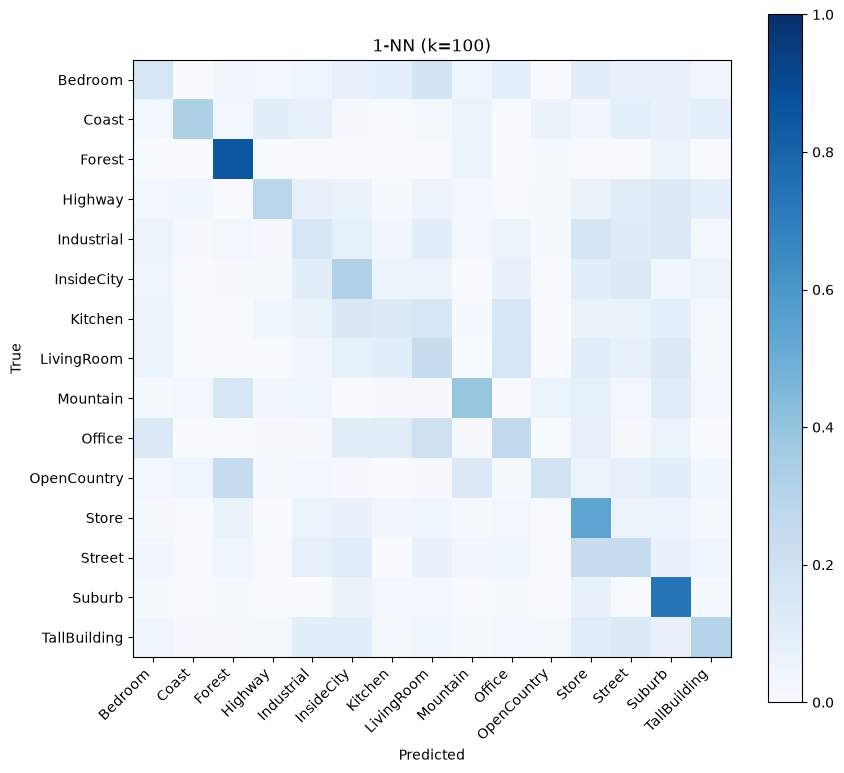

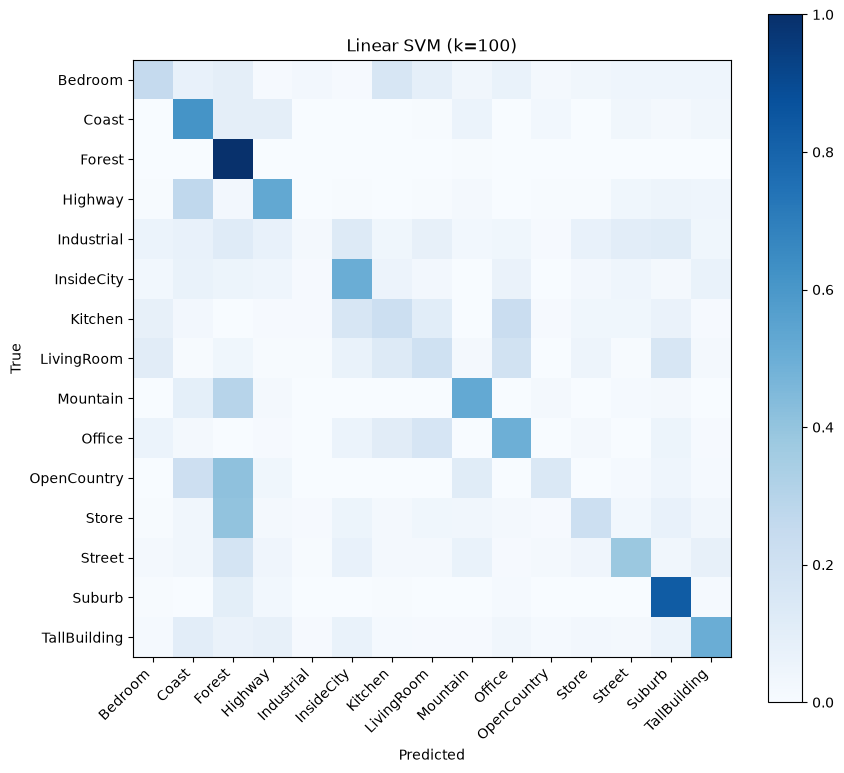

  Best k              : 100
  1-NN  test accuracy : 35.0%
  SVM   test accuracy : 42.9%


In [8]:
plot_confusion_matrix(test_labels, knn_preds, categories, title=f'1-NN (k={best_k})')
plot_confusion_matrix(test_labels, svm_preds, categories, title=f'Linear SVM (k={best_k})')

print("=" * 35)
print(f"  Best k              : {best_k}")
print(f"  1-NN  test accuracy : {knn_test_acc * 100:.1f}%")
print(f"  SVM   test accuracy : {svm_test_acc * 100:.1f}%")
print("=" * 35)

## 6. Discussion

The SVM consistently outperforms the 1-NN baseline across all vocabulary sizes. With k=100, the SVM reaches 42.3% test accuracy compared to 36.0% for 1-NN. This is expected: the SVM learns a global decision boundary from all training examples, while 1-NN relies on a single nearest neighbor and is sensitive to noise in the histograms.

The best vocabulary size is k=100. Smaller values (k=50) produce a representation that is too coarse — many visually different patches are mapped to the same word, losing discriminative power. Larger values (k=200, 500) do not improve accuracy and may hurt it slightly, as the histograms become sparser and harder to compare.

Looking at the confusion matrices, the most commonly confused categories are those that share similar low-level textures: for example, OpenCountry and Coast both contain large uniform regions (sky, water, sand), and Mountain and Forest share irregular, dense textures. These errors are expected in a bag-of-words system that has no notion of spatial structure.